# Data pre-processing

In [4]:
%load_ext autoreload
%autoreload 2

import io
import base64
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, clear_output
from matplotlib_venn import venn2
from matplotlib.figure import Figure as plt_Figure
from sklearn.preprocessing import LabelEncoder
from data_viz import (step_plot_distribution,
                      pie_chart_multilabels_proportion,
                      pie_chart_simple,
                      bar_plot_distribution_with_floating_text,
                      bar_plot_habitats_distribution_VS_syntaxons,
                      stack_bars_habitats,
                      upset_plot_habitats_per_soft_labeling,
                      jaccard_sim_habitat_soft_multilabeling,
                      stacked_bars_habitat_distribution,
                      bar_plot_habitats_soft_multilabel)
from stats import get_basic_stats

In [5]:
def fig_to_img(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    data = base64.b64encode(buf.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="margin-right:20px;">'

def file_to_img(path):
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="margin-right:20px;">'

def display_plots_side_by_side(figs):
    html = '<div style="display:flex; align-items:flex-start;">'
    for fig in figs:
        if isinstance(fig, plt_Figure):
            html += fig_to_img(fig)
        elif isinstance(fig, str):
            html += file_to_img(fig)
    html += '\n</div>'
    display(HTML(html))

## FloraVeg habitat labels

The FloraVeg habitats dataset is a collection of ground-level images associated with a EUNIS lvl3 habitat label. Some of the images are also geo-tagged with WGS4326 lon/lat values.

There are 3 CSV files:
- `metadata.csv`: contains the image samples and metadata associated
- `metadata_labels.csv`: contains the EUNIS habitat labels written as plain text description, with a merge key column named "syntaxons" which makes possible to associate samples with their label(s)
- `habitats_code.csv`: a translation table between plain text EUNIS habitats description and their code name _(e.g.: Arctic littoral biogenic habitats $\rightarrow$ MA21)_

⚠️ <span style="color:red"> **IMPORTANT: the merge key "syntaxons" in `metadata_labels.csv` is a NON UNIQUE matching key, meaning ONE sample syntaxon can be matched with SEVERAL EUNIS habitat labels** </span>

In [9]:
df_occurrences = pd.read_csv('metadata.csv')
df_labels = pd.read_csv('metadata_labels.csv')
df_code = pd.read_csv('habitats_code.csv').iloc[1:]  # Skipping 1st row because it contains a secondary header
df_code['code'] = df_code['code'].apply(lambda x: x.strip())
print(f'\033[1m● \x1B[4mOccurences\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_occurrences.shape} \n > \x1B[4mColumns\x1B[0m: {df_occurrences.columns.tolist()}')
display(df_occurrences.head(2))
print(f'\033[1m● \x1B[4mLabels\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_labels.shape} \n \x1B[4mColumns\x1B[0m: {df_labels.columns.tolist()}')
display(df_labels.head(2))
print(f'\033[1m● \x1B[4mLabels conversion table\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_code.shape} \n \x1B[4mColumns\x1B[0m: {df_code.columns.tolist()}')
display(df_code.head(2))

● Occurences: 
 > Shape: (5130, 12) 
 > Columns: ['filename_photos', 'syntaxon_floraveg', 'author_floraveg', 'country', 'id_floraveg', 'locality', 'author_name', 'domin_taxa', 'association', 'coords_precision', 'lat', 'lon']


,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon
0,Arunco_vulgaris-Lunarietum_redivivae2.jpg,Impatienti noli-tangere-Stachyion sylvaticae,Görs ex Mucina 1993,Czech Republic,12486,Ještědský hřbet (distr. Liberec),Petr Petřík,NaN,NaN,NaN,NaN,NaN
1,Carpinion_betuli_(eu)3.jpg,Carpinion betuli,Issler 1931,Bosnia and Herzegovina,14059,"Gradiška municipality, Cerovljani village, Dog...",Vladimir Stupar,"Carpinus betulus, Quercus robur",NaN,NaN,NaN,NaN


● Labels: 
 Shape: (1362, 6) 
 Columns: ['habitats', 'syntaxons', 'code', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']


,habitats,syntaxons,code,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,<>,NaN,code,description
1,"Atlantic, Baltic and Arctic sand beach",Salsolo-Minuartion peploidis,>,NaN,<,the type left of the qualifier is defined as a...


● Labels conversion table: 
 Shape: (396, 2) 
 Columns: ['code', 'name']


,code,name
1,MA,Marine habitats
2,N,Coastal habitats


In [14]:
print(f'\033[1m● \x1B[4mOccurences\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_occurrences.shape} \n > \x1B[4mColumns\x1B[0m: {df_occurrences.columns.tolist()}')
display(df_occurrences.head(1))
print(f'\033[1m● \x1B[4mLabels\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_labels.shape} \n \x1B[4mColumns\x1B[0m: {df_labels.columns.tolist()}')
display(df_labels.head(1))
print(f'\033[1m● \x1B[4mLabels conversion table\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_code.shape} \n \x1B[4mColumns\x1B[0m: {df_code.columns.tolist()}')
display(df_code.head(2))

df_occurrences_gps_only = df_occurrences.dropna(subset=["lon", "lat"])
df_occurrences_gps_only.to_csv('metadata_gps_only.csv', index=False)

● Occurences: 
 > Shape: (5130, 12) 
 > Columns: ['filename_photos', 'syntaxon_floraveg', 'author_floraveg', 'country', 'id_floraveg', 'locality', 'author_name', 'domin_taxa', 'association', 'coords_precision', 'lat', 'lon']


,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon
0,Arunco_vulgaris-Lunarietum_redivivae2.jpg,Impatienti noli-tangere-Stachyion sylvaticae,Görs ex Mucina 1993,Czech Republic,12486,Ještědský hřbet (distr. Liberec),Petr Petřík,NaN,NaN,NaN,NaN,NaN


● Labels: 
 Shape: (1362, 6) 
 Columns: ['habitats', 'syntaxons', 'code', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']


,habitats,syntaxons,code,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,<>,NaN,code,description


● Labels conversion table: 
 Shape: (396, 2) 
 Columns: ['code', 'name']


,code,name
1,MA,Marine habitats
2,N,Coastal habitats


## Coverage
The dataset is mainly focused on Europe, but some points land outside.<br>
_E.g.: point in Alask with lon/lat = (-149,37454166667, 68,452866666667) representing Dryadion integrifoliae_


<div style="display: flex; gap: 10px; align-items: center;">
  <img src="resources/FLoraVeg_Alaska_outlier.png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
  <img src="resources/FLoraVeg_Europe_extent_(small).png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
</div>

### A few statistics
There are **5 130 occurrences** with each 1 image and 1 FloraVeg ID.\
Amongst them, **3 527 (68.75%)** are geo-tagged and scattered over **2 272 unique plots**, while 1 603 (31.25%) are NOT geo-tagged.

The dataset has **248 habitats** registered.\
The data (occurrences), and the labels (EUNIS-lvl3 habitats and EUNIS-lvl3 habitat codes) are given in separate files and can be matched using a correspondances key `syntaxons`.\
However, columns `syntaxons` and `habitats` do not match 1-to-1. Each habitat matches 1 to 32 different syntaxons (also, in the labels file, some habitat-syntaxon pairs appear multiple times, e.g. habitat n°1, n°69...).

---

In [15]:
n_unique_fids, n_unique_labels, n_occu_valid_gps, n_occu_invalid_gps, n_occurrences, n_plots, n_unique_habitats = get_basic_stats(df_occurrences, df_labels, return_stats=True)

Nb occurrences (illustrated): 5130
Nb unique FloraVeg IDs: 5130
Occurrences: 3527 (68.75%) with GPS | 1603 (31.25%) without
Nb of unique plots with valid GPS: 2273

Nb unique habitats: 248
Nb unique syntaxons (from occurrences file): 567
Nb unique syntaxons (from labels file): 1088



,habitats,syntaxons,code,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,<>,NaN,code,description
1,"Atlantic, Baltic and Arctic sand beach",Salsolo-Minuartion peploidis,>,NaN,<,the type left of the qualifier is defined as a...
2,"Atlantic, Baltic and Arctic sand beach",Agropyro-Rumicion,<>,NaN,>,the type left of the qualifier is defined as a...



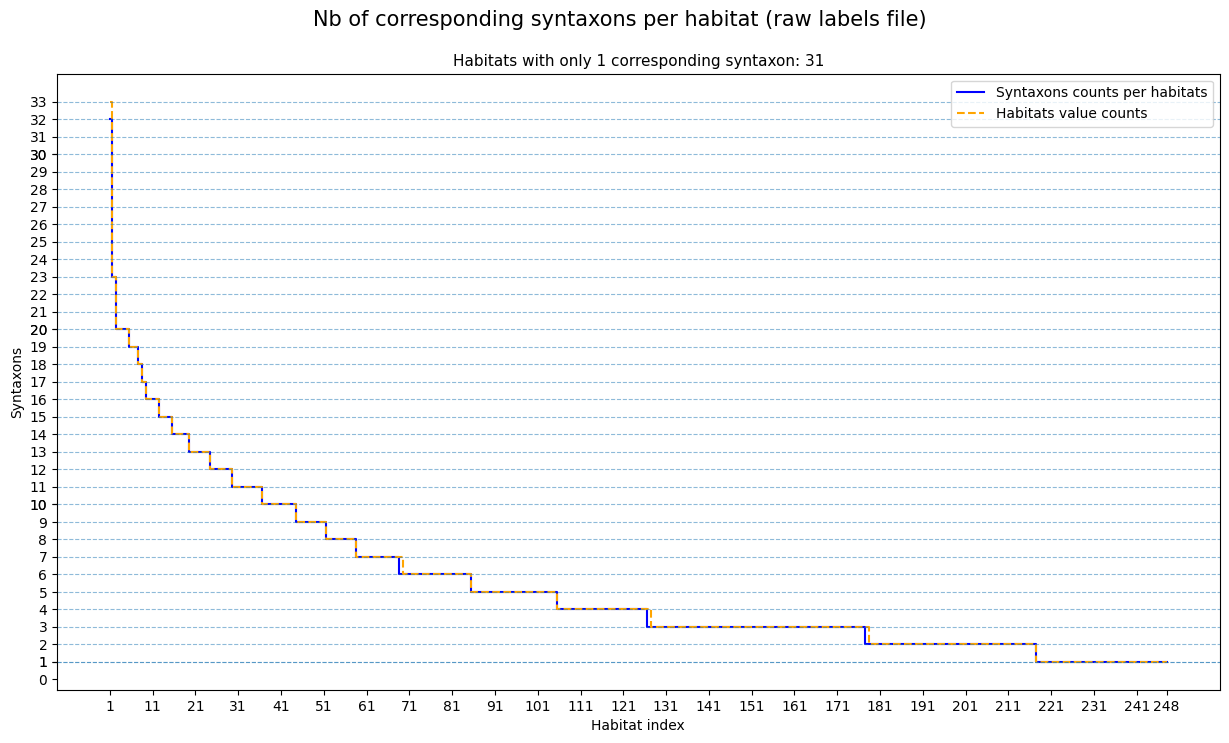
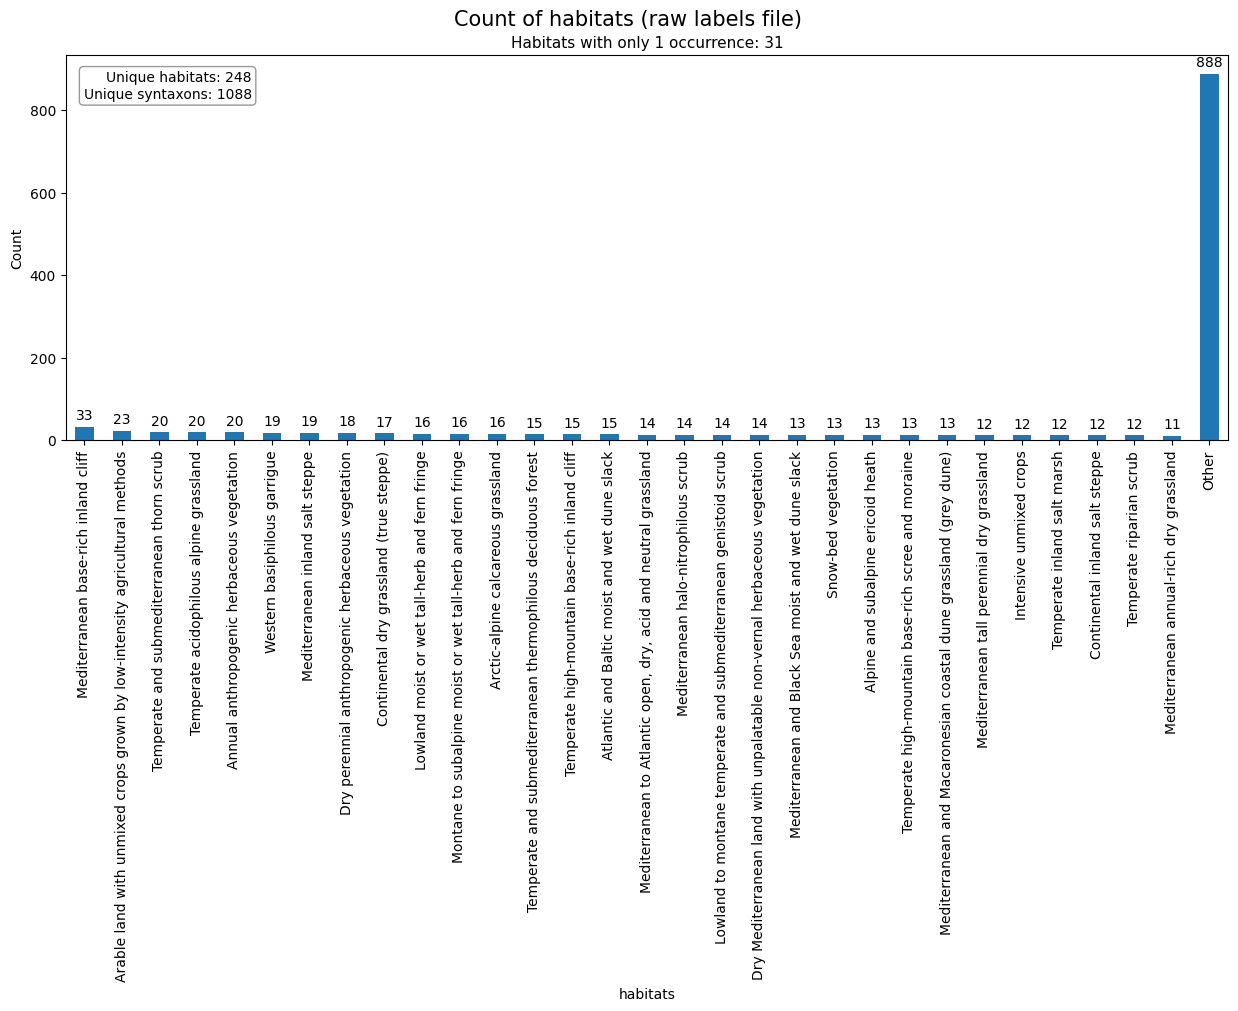

In [16]:
fig1, habitat_distrib = bar_plot_habitats_distribution_VS_syntaxons(df_labels, top_k=248, title='Nb of corresponding syntaxons per habitat (raw labels file)', plot_width=15, fp_out='resources/Habitats_VS_Syntaxons_dstribution(raw_labels).png', plot=False)
fig2, habitat_counts = bar_plot_distribution_with_floating_text(df_labels, 'habitats', top_k=30, title='Count of habitats (raw labels file)', plot_width=15, fp_out='resources/Count_of_habitats_(raw_labels).png', plot=False)
display_plots_side_by_side([fig1, fig2])

### Merging occurrences and labels

After merging files, **habitats match 1 to 326 occurrences**. Conversely, **occurrences match 1 to 5 labels**.

**86.69% (215) habitats** match at least 1 occurence, of which **8 (3.72%) habitats** match only **one occurrence**.\
**65.68% (3 179) occurrences** match only **one habitat**.

Outside of the scope of this project, FloraVeg registers 396 habitats (any level), of which 336 are of level-3. However, only 215 of those (~64%) are illustrated. And only 248 can be linked to samples because that's how many syntaxons we have to merge tables.

In [17]:
df_code['code'].nunique()

396

In [18]:
df_code_renamed = df_code.rename(columns={'code': 'habitats_code', 'name': 'habitats'}).iloc[1:]  # Skipping 1st row because it is a secondary header
df_labels_renamed = df_labels[['habitats', 'syntaxons']]
df_labels_with_code = pd.merge(df_labels_renamed, df_code_renamed, left_on='habitats', right_on='habitats')

df_occurrences_merged = pd.merge(df_occurrences, df_labels_with_code, left_on='syntaxon_floraveg', right_on='syntaxons')

print(f'\033[1m● \x1B[4mLabels with code\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_labels_with_code.shape} \n > \x1B[4mColumns\x1B[0m: {df_labels_with_code.columns.tolist()}')
display(df_labels_with_code.head(1))

print(f'\033[1m● \x1B[4mOccurrences with labels & code\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_occurrences_merged.shape} \n > \x1B[4mColumns\x1B[0m: {df_occurrences_merged.columns.tolist()}')
display(df_occurrences_merged.head(1))

df_occurrences_merged.to_csv('metadata_labels_merged.csv', index=False)
df_occurrences_merged_gps_only = df_occurrences_merged.dropna(subset=["lon", "lat"])
df_occurrences_merged_gps_only.to_csv('metadata_labels_merged_gps_only.csv', index=False)

● Labels with code: 
 > Shape: (1362, 3) 
 > Columns: ['habitats', 'syntaxons', 'habitats_code']


,habitats,syntaxons,habitats_code
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,N11


● Occurrences with labels & code: 
 > Shape: (7948, 15) 
 > Columns: ['filename_photos', 'syntaxon_floraveg', 'author_floraveg', 'country', 'id_floraveg', 'locality', 'author_name', 'domin_taxa', 'association', 'coords_precision', 'lat', 'lon', 'habitats', 'syntaxons', 'habitats_code']


,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon,habitats,syntaxons,habitats_code
0,Arunco_vulgaris-Lunarietum_redivivae2.jpg,Impatienti noli-tangere-Stachyion sylvaticae,Görs ex Mucina 1993,Czech Republic,12486,Ještědský hřbet (distr. Liberec),Petr Petřík,NaN,NaN,NaN,NaN,NaN,Lowland moist or wet tall-herb and fern fringe,Impatienti noli-tangere-Stachyion sylvaticae,R55


In [20]:
# Encoding labels. This step is done here to ensure stability of labels encoding throughout the training process
re_pattern_lvl3 = re.compile(r'^(?:MA2[A-Za-z0-9]{2,}|(?!MA2)[A-Za-z0-9]{3,})$')

# Encoding all EUNIS labels
le = LabelEncoder()
le.fit(df_code['code'].values)
df_code['code_ID'] = le.transform(df_code['code'].values)
df_code['Level_3'] = [bool(re_pattern_lvl3.match(x)) for x in df_code['code']]
assert df_code['code'].nunique() == df_code['code_ID'].nunique()
df_code.to_csv('habitats_code_encoded.csv', index=False)

# Encoding only level-3 EUNIS labels illustrated in our dataset
habitats_code_lvl_3 = [x for x in df_code['code'] if bool(re_pattern_lvl3.match(x))]
le_lvl3 = LabelEncoder()
le_lvl3.fit(df_occurrences_merged['habitats_code'].unique())
df_occurrences_merged['habitats_code_ID'] = le_lvl3.transform(df_occurrences_merged['habitats_code'])
assert len(habitats_code_lvl_3) == df_code['Level_3'].sum()
assert df_occurrences_merged['habitats_code_ID'].max() == df_occurrences_merged['habitats_code'].nunique()-1
df_occurrences_merged.to_csv('metadata_labels_merged_encoded.csv', index=False)

df_occurrences_merged_gps_only = df_occurrences_merged.dropna(subset=["lon", "lat"])
df_occurrences_merged_gps_only.to_csv('metadata_labels_merged_gps_only_encoded.csv', index=False)

print(f'FloraVeg registers a total of {len(df_code)} possible habitats. Of which, {len(habitats_code_lvl_3)} are of level-3.')

FloraVeg registers a total of 396 possible habitats. Of which, 336 are of level-3.



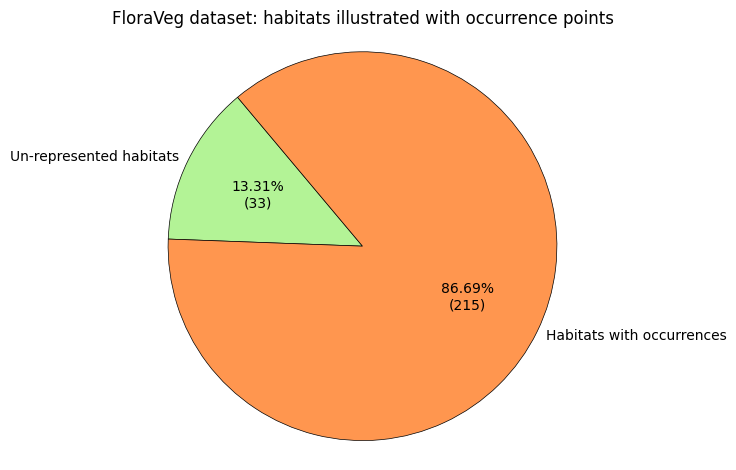
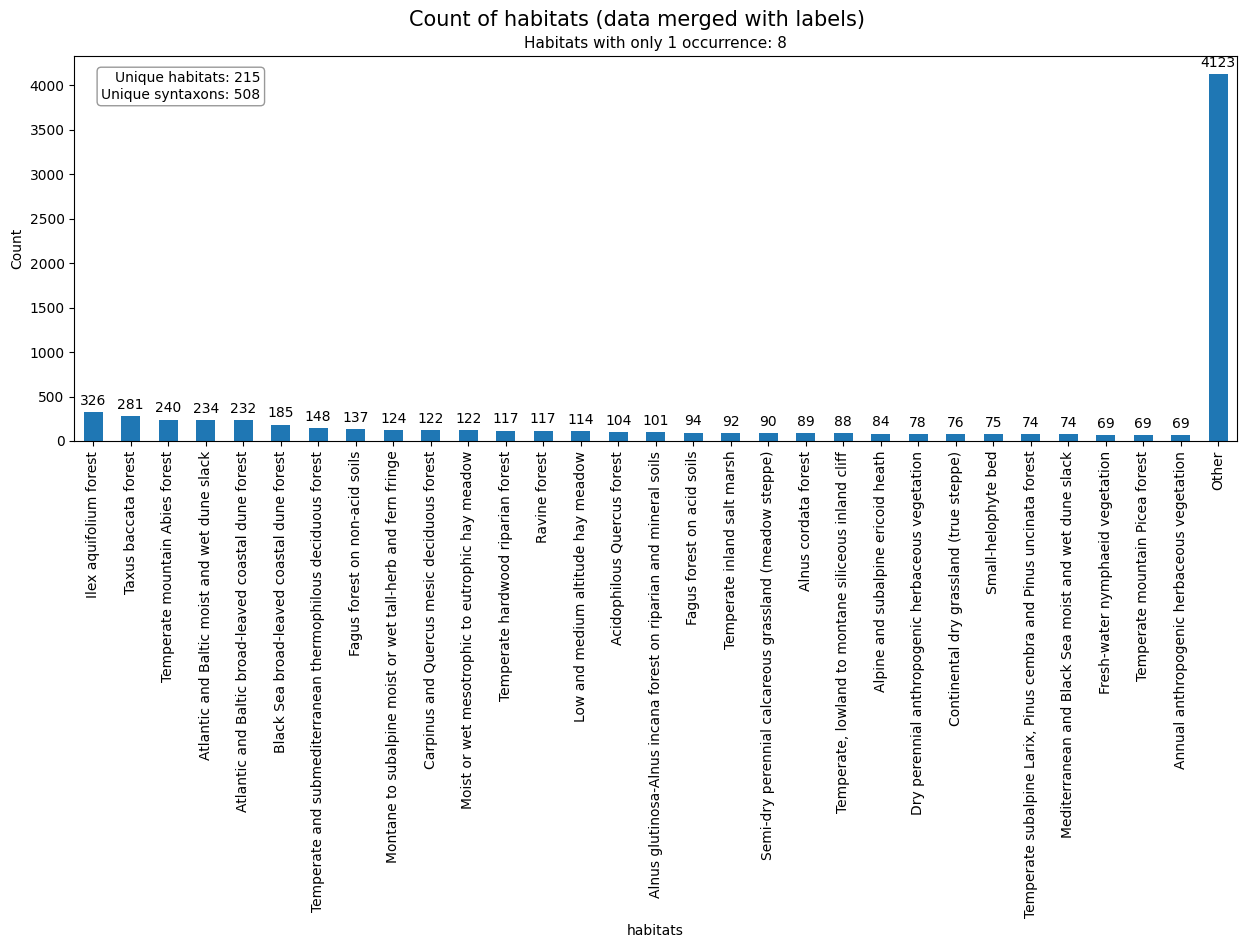

In [21]:
values = [df_labels_with_code['habitats'].unique().shape[0] - df_occurrences_merged['habitats'].unique().shape[0],
          df_occurrences_merged['habitats'].unique().shape[0]]
labels = ['Un-represented habitats', 'Habitats with occurrences']
title = "FloraVeg dataset: habitats illustrated with occurrence points"

fig1 = pie_chart_simple(values, labels, title, fp_out='resources/FloraVeg_habitats_with_occu.png', plot=False)
fig2, habitat_counts_merge = bar_plot_distribution_with_floating_text(df_occurrences_merged, 'habitats', top_k=30, title='Count of habitats (data merged with labels)', plot_width=15, fp_out='resources/habitat_distribution_on_metadata_merged_with_labels.png', plot=False)

display_plots_side_by_side([fig1, fig2])


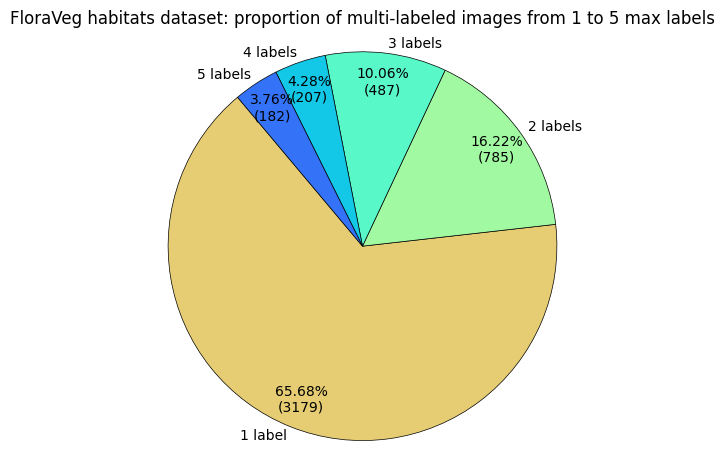
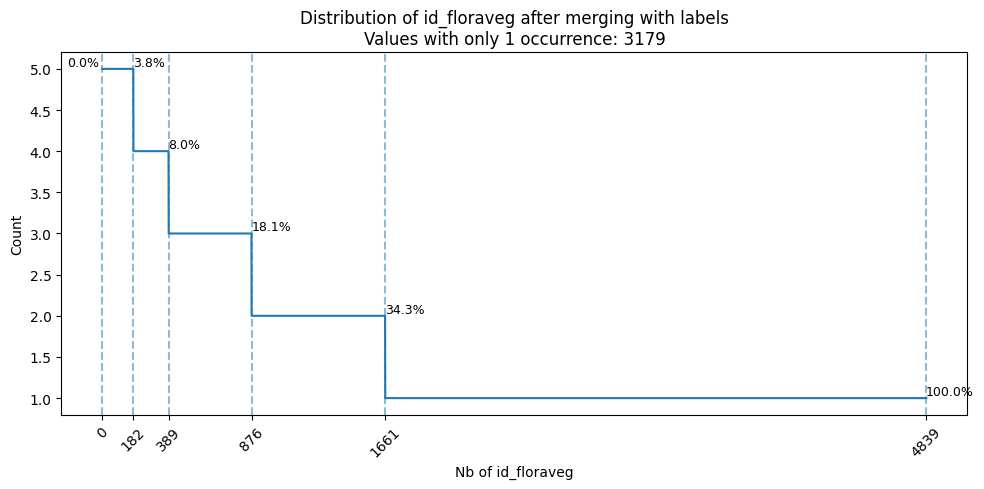

In [22]:
fig2, counts, df_counts_percentage = step_plot_distribution(df_occurrences_merged, 'id_floraveg',  fp_out='resources/occurrences_distribution_after_labels_merge.png', plot=False)
fig1 = pie_chart_multilabels_proportion(df_counts_percentage, fp_out='resources/Multi-labeled habitats proportion.png', plot=False)

display_plots_side_by_side([fig1, fig2])

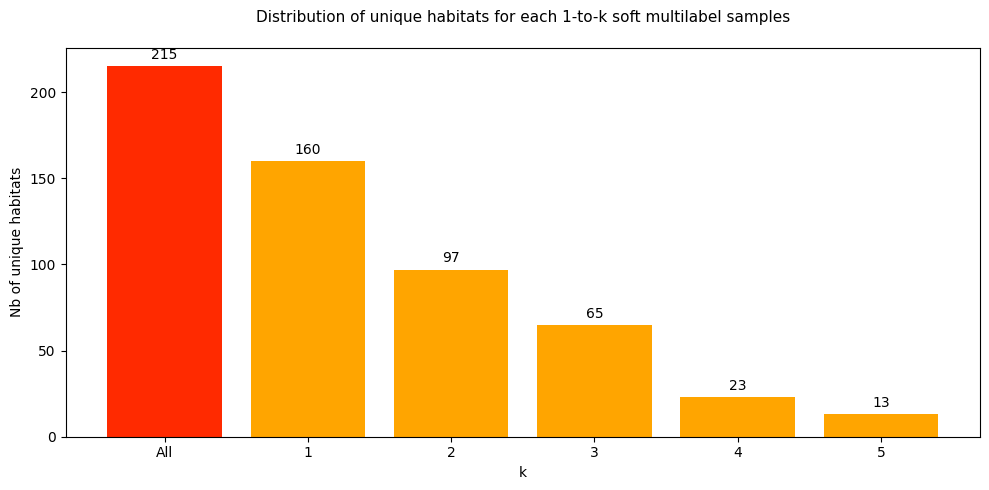

In [14]:
fig1 = bar_plot_habitats_soft_multilabel(df_occurrences_merged, counts, 'id_floraveg', fp_out='resources/Habitats_distribution_soft_multilabeling.png', plot=True)


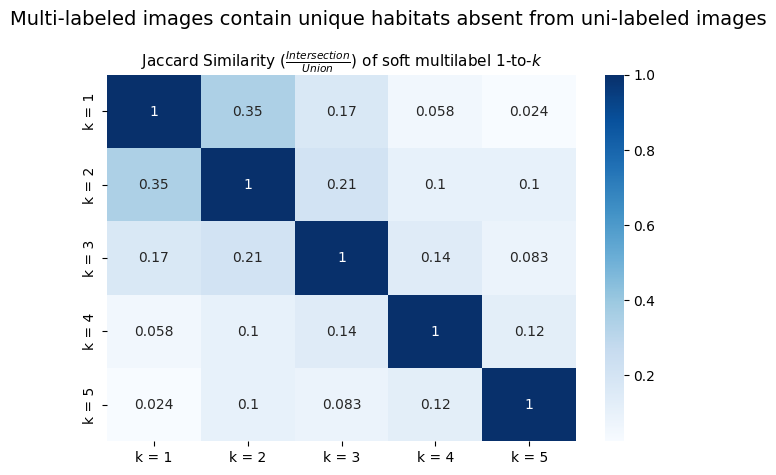
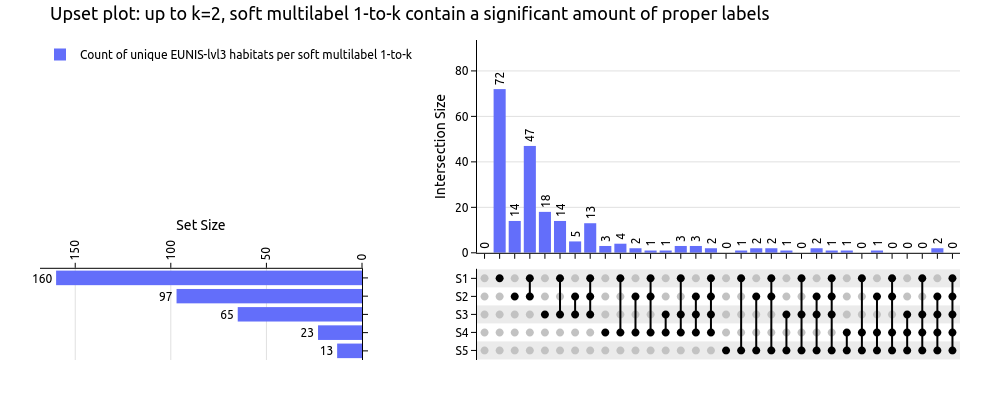

In [15]:
fig1 = upset_plot_habitats_per_soft_labeling(df_occurrences_merged, counts, plot=False)
fig2 = jaccard_sim_habitat_soft_multilabeling(counts, df_occurrences_merged, fp_out='resources/Jaccard_similarity_habitats_soft_labeling.png')
clear_output()
display_plots_side_by_side([fig2, 'resources/upset_plot_habitats_per_soft_labelling.png'])

### Distribution of habitat labels in partial multi-labeled images

To address the partial multi-labeling, various training strategies can be implemented:

- **B0.** **Pipeline level**: Make the model learn multiple times different labels for the same image by passing said image multiple times
    - Upside: all labels are seen the same amount of times per batch
    - Downside: this will introduce bias
---
- **B1.** **Dataloader level**: Iterate over the unique FloraVeg IDs and randomly sample a label, per batch
    - Upside: easy to implement
    - Downside: if the multi-labeled images are often tied to the same labels, the later will be harder to predict because they will have been seen fewer times
---
- **B2.** **Loss level**: Compute a custom loss with that takes into account the multiplicity of labels and weighs everything to give equal weights to all labels
    - Upside: fine-grain solution with possible optimum in labels equity
    - Downside: hard to implement and tune

In [16]:
df_occurrences_merged['habitats_code_lvl1'] = df_occurrences_merged['habitats_code'].apply(lambda x: re.match(r'[A-Za-z]+', x)[0])
df_occurrences_merged[df_occurrences_merged['id_floraveg'].isin(counts[counts > 1].index)].head(2)

,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon,habitats,syntaxons,habitats_code,habitats_code_lvl1
1,Carpinion_betuli_(eu)3.jpg,Carpinion betuli,Issler 1931,Bosnia and Herzegovina,14059,"Gradiška municipality, Cerovljani village, Dog...",Vladimir Stupar,"Carpinus betulus, Quercus robur",NaN,NaN,NaN,NaN,Atlantic and Baltic broad-leaved coastal dune ...,Carpinion betuli,N1D,N
2,Carpinion_betuli_(eu)3.jpg,Carpinion betuli,Issler 1931,Bosnia and Herzegovina,14059,"Gradiška municipality, Cerovljani village, Dog...",Vladimir Stupar,"Carpinus betulus, Quercus robur",NaN,NaN,NaN,NaN,Black Sea broad-leaved coastal dune forest,Carpinion betuli,N1E,N


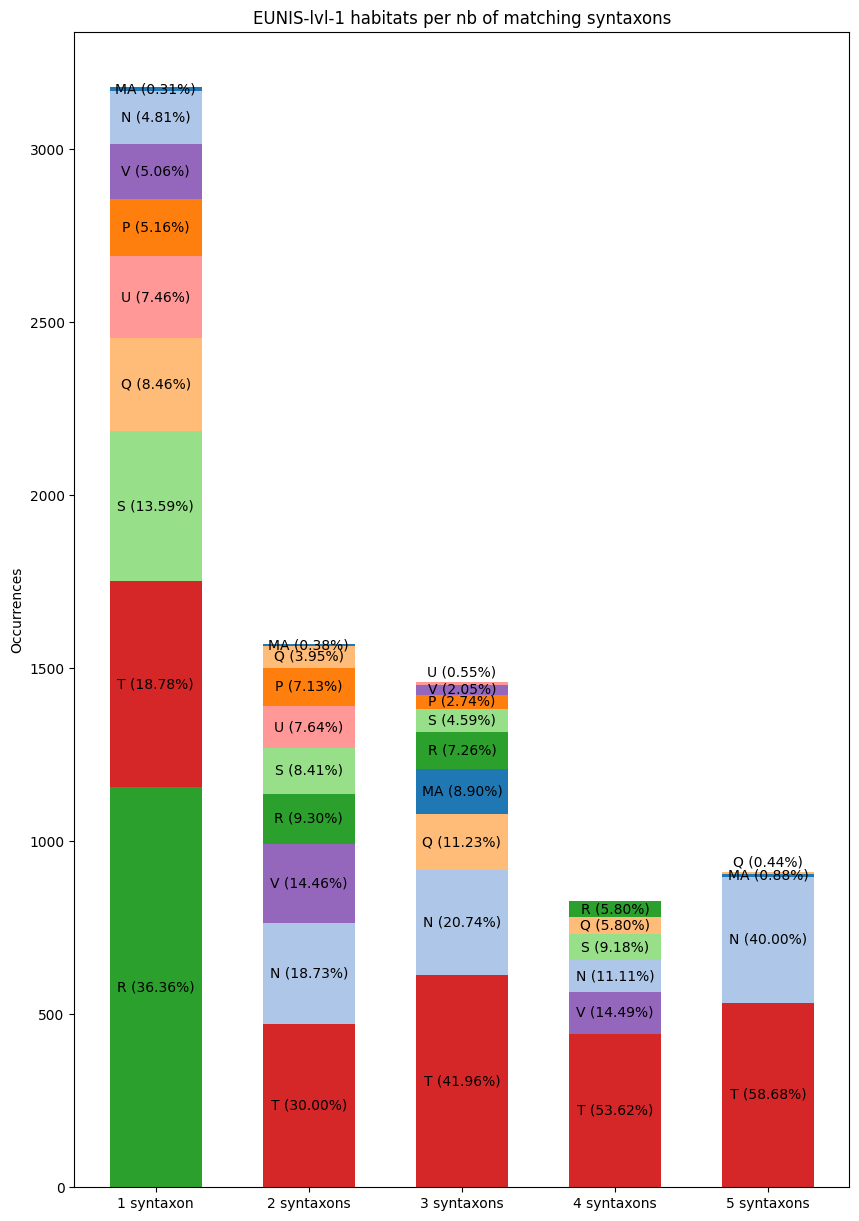

In [17]:
_ = stack_bars_habitats(df_occurrences_merged, counts, df_counts_percentage, fp_out='resources/Stack_bar_plot_multi-taxons_habitats.png', plot=True)

### ⚠️ Test split ⚠️
Several strategies are proposed to generate the test split:

- **S0: naive split** \
Splitting based on plot ID (id_floraveg).
    - _Advantages_: No image leakage between train & test due to the soft-multilabelling issue (contrary to S1).
    - _Drawbacks_: The distribution of k-soft multilabeled samples is NOT preserved. One split could have all the 1-to-5 samples when the other would have none.

---

- **S1: stratified split (labels)** \
Splitting based on the distribution of labels, making sure each split has the same labels distribution (if possible).
    - _Advantages_: Preserves the labels distribution.
    - _Drawbacks_: There may be **data leakage** due to the fact that samples can have more than 2 labels, therefore a 3-multilabel plot (floraveg_id) could be split both to trian and test, with different labels.

---

- **S1-bis: stratified split (k)** \
Splitting based on the distribution of k-multilabeled plot ID (id_floraveg).
    - _Advantages_: Preserves the distribution of k-multilabels samples in train and test.
    - _Drawbacks_: Distribution of labels is NOT ensured. However there is no visual image data leakage between train and test.

---

- **S2: spatial split** \
Splitting based on geolocation. This method can only be performed over geo-tagged occurrences.
    - _Advantages_: Dampens potential geographical bias. No image data leakage because a plot (id_floraveg) is defined (partly ?) by its GPS coords; so selecting by GPS automatically selects entire plots regardless of the 1-to-k soft multilabelling effect.
    - _Drawbacks_: Looses 31.25% of available data (which is not geo-tagged). Does NOT preserve labels distribution.


- **S0 split**

In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split

def S0_split(df, out_name, val_size=0.1, random_state=42):
    unique_ids = df["id_floraveg"].unique()
    train_ids, val_ids = train_test_split(
        unique_ids,
        test_size=val_size,
        random_state=random_state
    )

    train_df = df[df["id_floraveg"].isin(train_ids)].copy()
    val_df = df[df["id_floraveg"].isin(val_ids)].copy()

    train_path = f"{out_name}_train.csv"
    val_path = f"{out_name}_test.csv"

    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)

    print(f"Train saved to: {train_path}")
    print(f"Val saved to: {val_path}")
    print(f"Train size: {len(train_df)}")
    print(f"Val size: {len(val_df)}")

    return train_df, val_df

S0_train_df, S0_test_df = S0_split(df_occurrences_merged, 'metadata_labels_merged_S0-10%', val_size=0.10)

Train saved to: metadata_labels_merged_S0-10%_train.csv
Val saved to: metadata_labels_merged_S0-10%_test.csv
Train size: 7138
Val size: 810


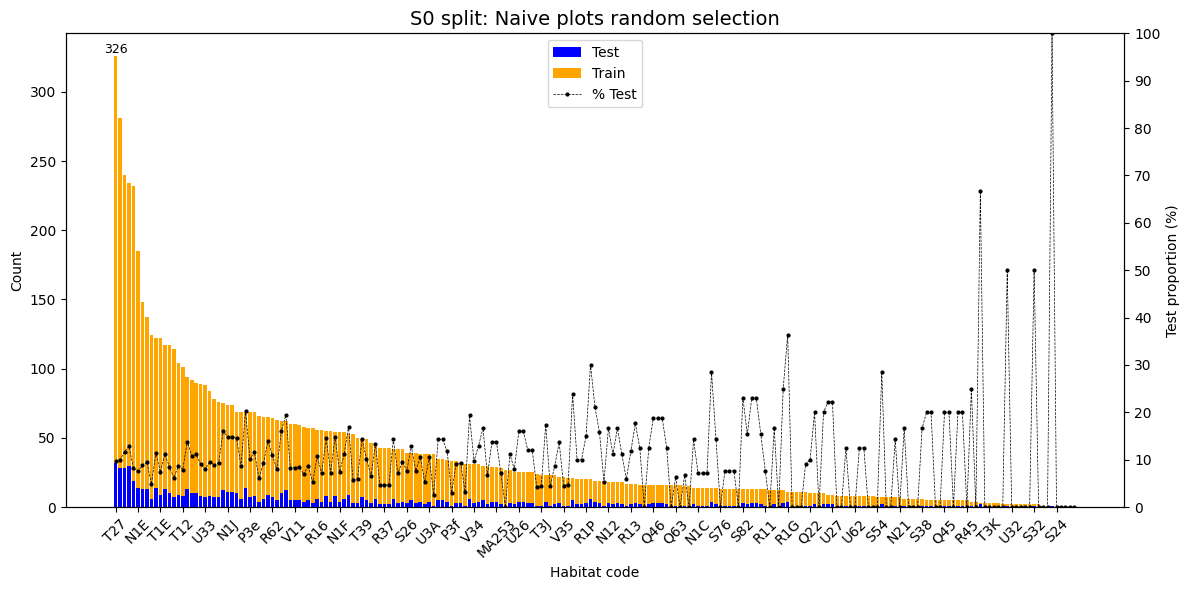

In [113]:
fig0 = stacked_bars_habitat_distribution(S0_train_df, S0_test_df, title='S0 split: Naive plots random selection', fp_out='resources/S0_split.png')

- **S1 split**


In [136]:
from toolbox.split_obs_per_column_frequency import main as split_obs_per_column_frequency

input_path = 'metadata_labels_merged_encoded.csv'
output_name = 'metadata_labels_merged_S1_stratified'
filter_id = 'habitats_code'
sep = ','
val_ratio = 0.1033
keep_rares = 1

split_obs_per_column_frequency(input_path, output_name, filter_id, sep, val_ratio, keep_rares)

  0%|                                                   | 0/215 [00:00<?, ?it/s]/home/tlarcher/Documents/Pl@ntNet/git/malpolon/examples/custom_train/multiscale_jrc/dataset/habitats_gpn25_eva/FLoraVeg/toolbox/split_obs_per_column_frequency.py:98: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pa_val = pd.concat([pa_val, df_slice.sample(n=round(n_sid * val_ratio))])
100%|███████████████████████████████████████| 215/215 [00:00<00:00, 2497.11it/s]

Exported train_without_val, val, and train_val_split_by_species_frequency csvs.
Rare classes were detected in the dataset: {'MA252': np.int64(9), 'U27': np.int64(9), 'MA251': np.int64(8), 'S65': np.int64(8), 'U62': np.int64(8), 'T23': np.int64(8), 'U34': np.int64(8), 'S71': np.int64(8), 'U22': np.int64(8), 'R1H': np.int64(8), 'S92': np.int64(8), 'R31': np.int64(7), 'T33': np.int64(7), 'S54': np.int64(7), 'N21': np.int64(7), 'R36': np.int64(7), 'T24': np.int64(7), 'S38': np.int64(6), 'T3B': np.int64(6), 'U23': np.int64(6), 'MA221': np.int64(6), 'S21': np.int64(6), 'U29': np.int64(5), 'T25': np.int64(5), 'Q44': np.int64(5), 'Q45': np.int64(5), 'R33': np.int64(5), 'R19': np.int64(5), 'R42': np.int64(5), 'R15': np.int64(5), 'S75': np.int64(5), 'R45': np.int64(5), 'P3a': np.int64(4), 'S52': np.int64(4), 'N17': np.int64(3), 'S63': np.int64(3), 'T3K': np.int64(3), 'Q23': np.int64(3), 'R52': np.int64(3), 'U72': np.int64(2), 'N18': np.int64(2), 'U32': np.int64(2), 'S32': np.int64(2), 'S33': np.

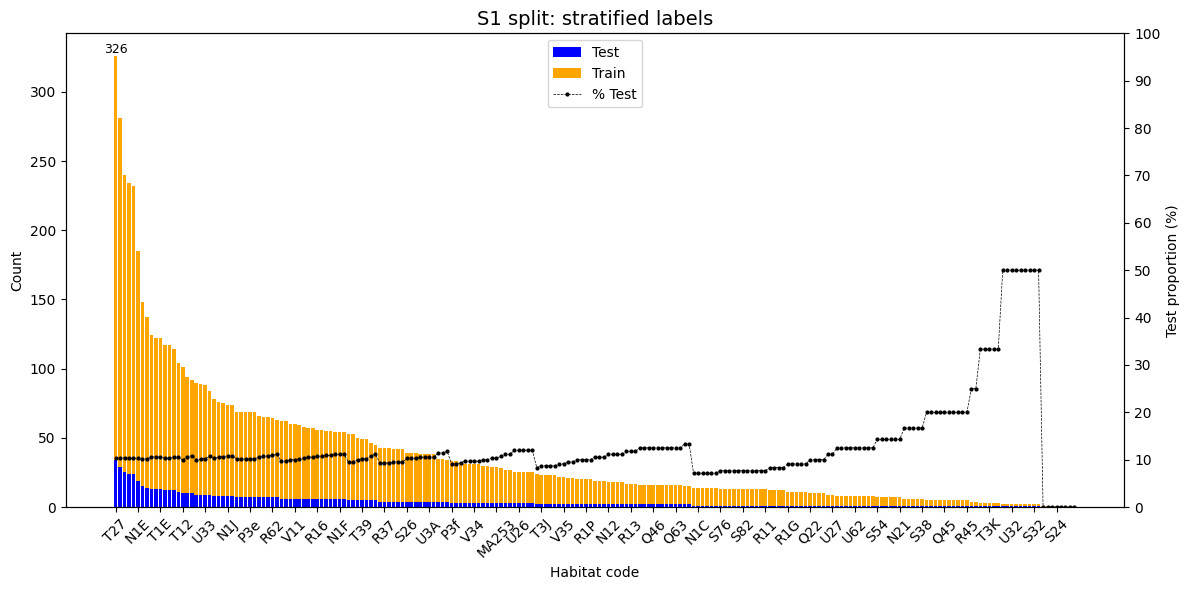

In [137]:
S1_train_df = pd.read_csv('metadata_labels_merged_S1_stratified_split-10.33%_train.csv')
S1_test_df = pd.read_csv('metadata_labels_merged_S1_stratified_split-10.33%_test.csv')
fig1 = stacked_bars_habitat_distribution(S1_train_df, S1_test_df, title='S1 split: stratified labels', suptitle='', fp_out='resources/S1_split.png')

- **S1-bis split**

In [116]:
def S1_bis_split(df, out_name, test_size=0.1, random_state=42):
    counts_per_k_multilabel = counts.groupby(counts).groups
    train_ids_multi_k, test_ids_multi_k = [], []
    for k, ids in counts_per_k_multilabel.items():
        df_k = df[df['id_floraveg'].isin(ids)]
        train_ids, test_ids = train_test_split(
            df_k["id_floraveg"].unique(),
            test_size=test_size,
            random_state=random_state
        )
        train_ids_multi_k.extend(train_ids)
        test_ids_multi_k.extend(test_ids)

    train_df = df[df["id_floraveg"].isin(train_ids_multi_k)].copy()
    test_df = df[df["id_floraveg"].isin(test_ids_multi_k)].copy()
    train_path = f"{out_name}_train.csv"
    test_path = f"{out_name}_test.csv"

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print(f"Train saved to: {train_path}")
    print(f"Test saved to: {test_path}")
    print(f"Train size: {len(train_df)}")
    print(f"Test size: {len(test_df)}")

    return train_df, test_df

S1_bis_train_df, S1_bis_test_df = S1_bis_split(df_occurrences_merged, 'metadata_labels_merged_S1bis-10%', test_size=0.10)

Train saved to: metadata_labels_merged_S1bis-10%_train.csv
Test saved to: metadata_labels_merged_S1bis-10%_test.csv
Train size: 7146
Test size: 802


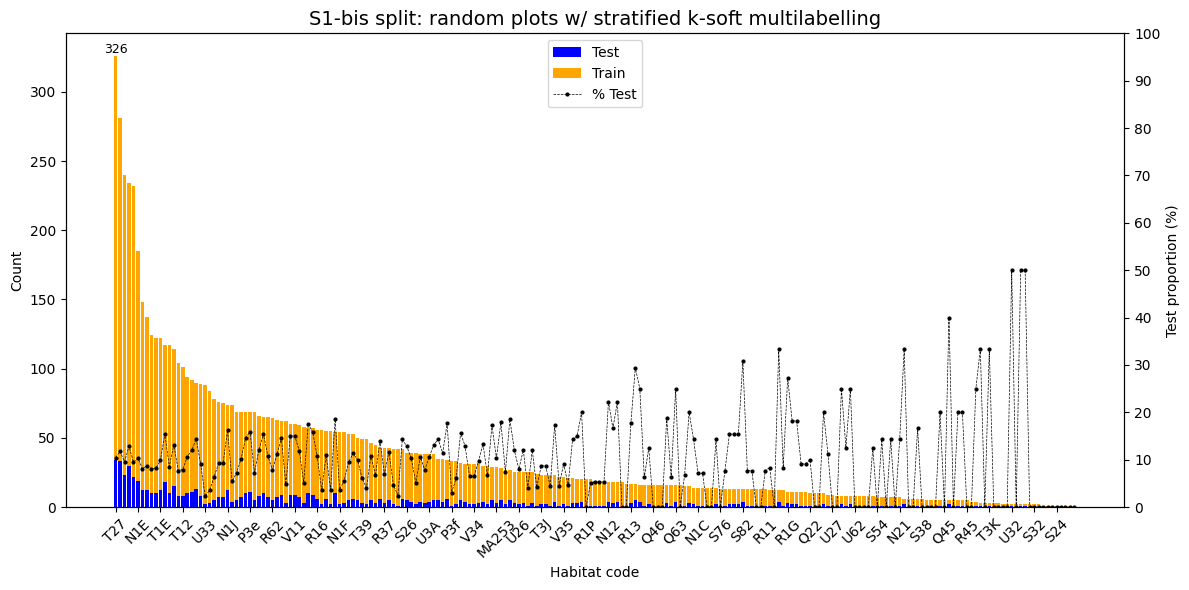

In [117]:
fig1_bis = stacked_bars_habitat_distribution(S1_bis_train_df, S1_bis_test_df, title='S1-bis split: random plots w/ stratified k-soft multilabelling', fp_out='resources/S1-bis_split.png')

- **S2 split**

In [143]:
from toolbox.split_obs_spatially import main as split_obs_spatially

input_path = 'metadata_labels_merged_gps_only_encoded.csv'
spacing = 0.54/60  # 0.54arc-minutes ~1km
col_lon = 'lon'
col_lat = 'lat'
val_size = 0.1033  # 530 occurrences
plot = False

split_obs_spatially(input_path, spacing, plot, val_size, col_lon, col_lat)

/!\ illustration no longer matches the current files /!\

<div style="display: flex; gap: 10px; align-items: center;">
  <img src="resources/FloraVeg_Europe_data_split_0.54min.png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
  <img src="resources/FloraVeg_spatial_split_0.54min.png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
</div>

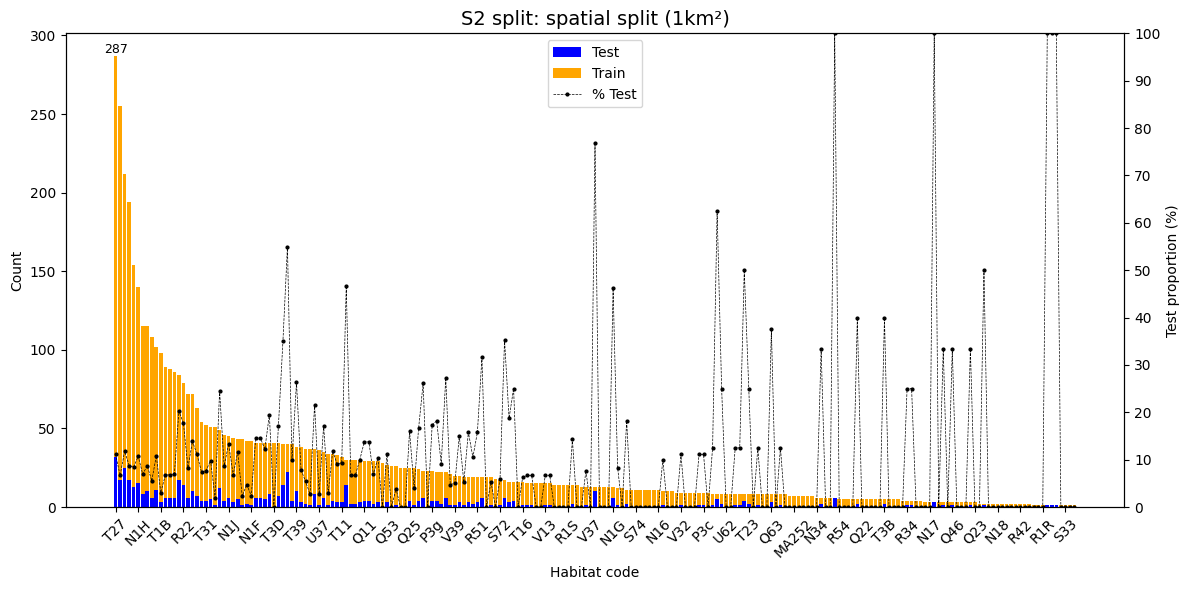

In [146]:
S2_train_df = pd.read_csv('metadata_labels_merged_gps_only_S2_train-0.54min.csv')               
S2_test_df = pd.read_csv('metadata_labels_merged_gps_only_S2_test-0.54min.csv')
fig2 = stacked_bars_habitat_distribution(S2_train_df, S2_test_df, title='S2 split: spatial split (1km²)', fp_out='resources/S2_split.png')

In [147]:
overlap = len(np.intersect1d(S2_train_df['id_floraveg'], S2_test_df['id_floraveg']))
if overlap > 0:
    print(f'⚠️ S2 split has {overlap} images leaking from train to test. ⚠️')
else:
    print('✅ S2 split (sptial) has NO image leakage between train and test. ✅')

✅ S2 split (sptial) has NO image leakage between train and test. ✅


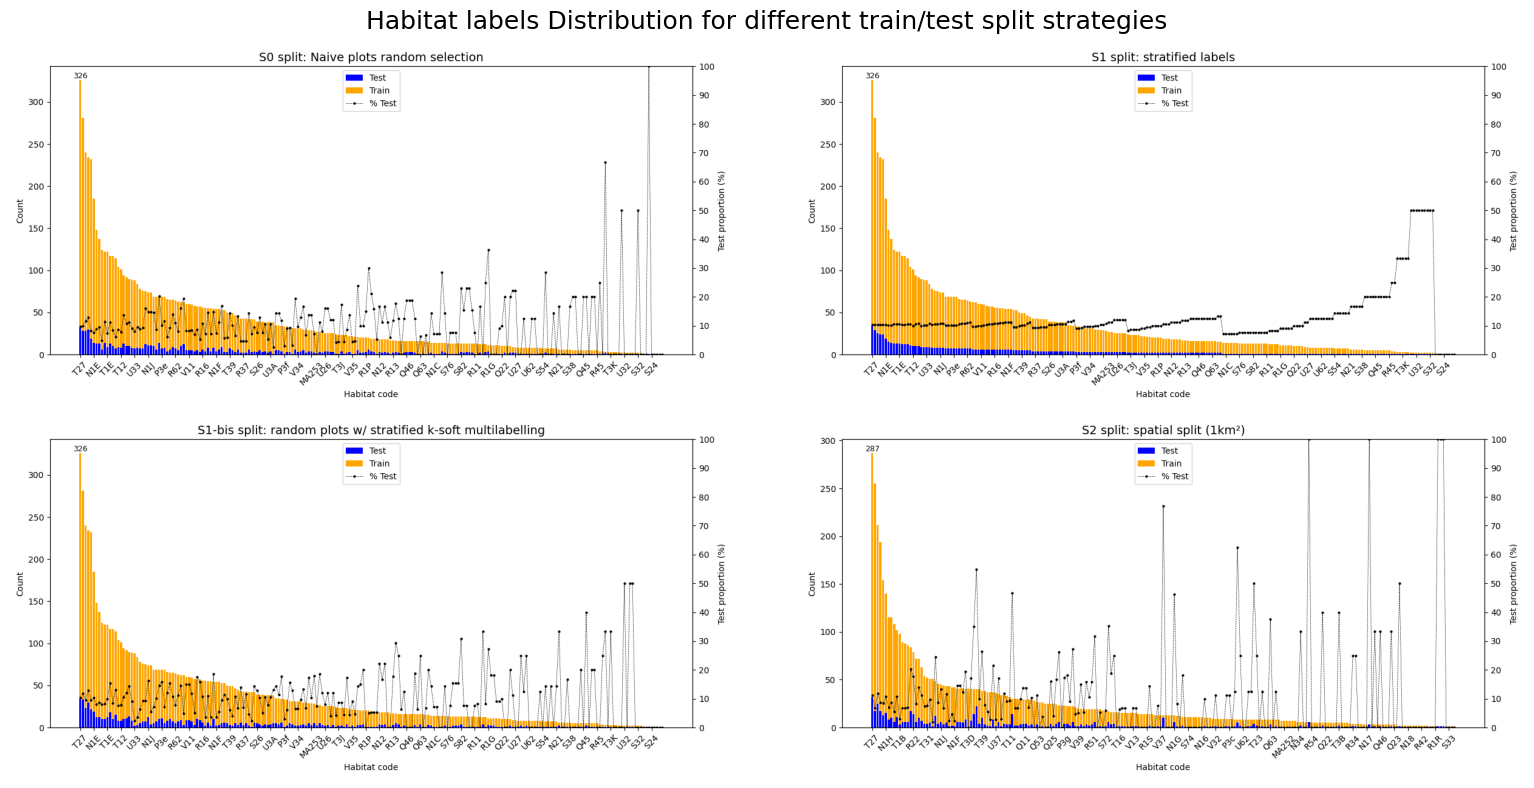

In [148]:
from PIL import Image

paths = [
    "resources/S0_split.png",
    "resources/S1_split.png",
    "resources/S1-bis_split.png",
    "resources/S2_split.png"
]

# Load images
images = [Image.open(p) for p in paths]

# Create grid
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

for ax, img in zip(axs.flatten(), images):
    ax.imshow(img)
    ax.axis("off")  # hide axes

plt.suptitle('Habitat labels Distribution for different train/test split strategies', fontsize=18)
plt.tight_layout()
plt.show()

## Test set 1-to-k img-label correspondance

In [35]:
df_test_stratified_filename = 'metadata_labels_merged_S1_stratified_split-10.33%_test'
df_test_spatial_filename = 'metadata_labels_merged_gps_only_S2_test-0.54min'
df_test_S1bis_filename = 'metadata_labels_merged_S1bis-10%_test'

df_test_freq = pd.read_csv(f'{df_test_stratified_filename}.csv')
df_test_spatial = pd.read_csv(f'{df_test_spatial_filename}.csv')
df_test_S1bis = pd.read_csv(f'{df_test_S1bis_filename}.csv')
samples_per_n_labels = counts.groupby(counts).groups

In [37]:
df_test_S1bis.head(1)

,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon,habitats,syntaxons,habitats_code,habitats_code_ID
0,Arunco_vulgaris-Lunarietum_redivivae2.jpg,Impatienti noli-tangere-Stachyion sylvaticae,Görs ex Mucina 1993,Czech Republic,12486,Ještědský hřbet (distr. Liberec),Petr Petřík,NaN,NaN,NaN,NaN,NaN,Lowland moist or wet tall-herb and fern fringe,Impatienti noli-tangere-Stachyion sylvaticae,R55,102


In [40]:
dfs_in = {
    # 'S1 (stratified labels)': df_test_freq,
    # 'S2 (spatial)': df_test_spatial,
    f'{df_test_S1bis_filename}': df_test_S1bis,
}

for name_in, df_in in dfs_in.items():
    print(f'>>> {name_in}')
    df_out = {}
    for k, ids in samples_per_n_labels.items():
        df_out[k] = df_in[df_in['id_floraveg'].isin(ids)]

    verif_size = 0
    ulabels = 0
    for k, df in df_out.items():
        df.to_csv(f'{name_in}_1-to-{k}.csv')
        verif_size += len(df)
        ulabels += df['habitats_code'].nunique()
        print(f'Nb of samples for k = {k}: {len(df)} with {df['habitats_code'].nunique()} unique labels.')

    print(f'Split test df ({name_in} split) in 1-to-k img-label subsets (total of {verif_size} samples and {ulabels} unique labels)\n')

>>> metadata_labels_merged_S1bis-10%_test
Nb of samples for k = 1: 318 with 106 unique labels.
Nb of samples for k = 2: 158 with 53 unique labels.
Nb of samples for k = 3: 147 with 48 unique labels.
Nb of samples for k = 4: 84 with 13 unique labels.
Nb of samples for k = 5: 95 with 13 unique labels.
Split test df (metadata_labels_merged_S1bis-10%_test split) in 1-to-k img-label subsets (total of 802 samples and 233 unique labels)


In [37]:
dfs_test_stratified_sk = {}
dfs_test_spatial_sk = {}
for k, ids in samples_per_n_labels.items():
    dfs_test_stratified_sk[k] = df_test_freq[df_test_freq['id_floraveg'].isin(ids)]
    dfs_test_spatial_sk[k] = df_test_spatial[df_test_spatial['id_floraveg'].isin(ids)]

In [45]:
verif_size = 0
ulabels = 0
for k, df in dfs_test_stratified_sk.items():
    df.to_csv(f'{df_test_stratified_filename}_1-to-{k}.csv')
    verif_size += len(df)
    ulabels += df['habitats_code'].nunique()
    print(f'Nb of samples for k = {k}: {len(df)} with {df['habitats_code'].nunique()} unique labels.')
    
print(f'Split test df (freq split) in 1-to-k img-label subsets (total of {verif_size} samples and {ulabels} unique labels)')

verif_size = 0
ulabels = 0
for k, df in dfs_test_spatial_sk.items():
    df.to_csv(f'{df_test_spatial_filename}_1-to-{k}.csv')
    verif_size += len(df)
    ulabels += df['habitats_code'].nunique()
    print(f'Nb of samples for k = {k}: {len(df)} with {df['habitats_code'].nunique()} unique labels.')
print(f'Split test df (spatial split) in 1-to-k img-label subsets (total of {verif_size} samples and {ulabels} unique labels)')

Nb of samples for k = 1: 333 with 129 unique labels.
Nb of samples for k = 2: 178 with 73 unique labels.
Nb of samples for k = 3: 153 with 50 unique labels.
Nb of samples for k = 4: 77 with 21 unique labels.
Nb of samples for k = 5: 99 with 8 unique labels.
Split test df (freq split) in 1-to-k img-label subsets (total of 840 samples and 281 unique labels)
Nb of samples for k = 1: 244 with 74 unique labels.
Nb of samples for k = 2: 124 with 44 unique labels.
Nb of samples for k = 3: 93 with 29 unique labels.
Nb of samples for k = 4: 24 with 8 unique labels.
Nb of samples for k = 5: 85 with 8 unique labels.
Split test df (spatial split) in 1-to-k img-label subsets (total of 570 samples and 163 unique labels)
